# Diagnostics!

This notebook reads the HDF5 files written by the Fortran solver, plots the two individual horizons and the common horizon, and computes the common-horizon area.

#### Importing functions

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from pathlib import Path

#### Data produced

In [20]:
data_dir = Path('./data')

def orient_h(h_raw, theta, phi, name):
    h = np.array(h_raw, dtype=float)

    # If dimensions are swapped in file, fix directly.
    if h.shape == (len(phi), len(theta)):
        h = h.T

    # If Ntheta == Nphi, shape check cannot detect transposition.
    # Use axisymmetry heuristic: variation across phi should be much smaller
    # than variation across theta for this equal-mass BL setup.
    phi_var = np.mean(np.std(h, axis=1))
    theta_var = np.mean(np.std(h, axis=0))
    if phi_var > theta_var:
        h = h.T
        phi_var = np.mean(np.std(h, axis=1))
        theta_var = np.mean(np.std(h, axis=0))

    print(f"{name}: phi_var={phi_var:.3e}, theta_var={theta_var:.3e}, shape={h.shape}")
    return h

with h5py.File(data_dir / 'BH1_horizon.h5', 'r') as f:
    theta1 = f['theta'][:]
    phi1 = f['phi'][:]
    h1_raw = f['h'][:]

with h5py.File(data_dir / 'BH2_horizon.h5', 'r') as f:
    theta2 = f['theta'][:]
    phi2 = f['phi'][:]
    h2_raw = f['h'][:]

with h5py.File(data_dir / 'horizon_common.h5', 'r') as f:
    theta_c = f['theta'][:]
    phi_c = f['phi'][:]
    h_c_raw = f['h'][:]

h1 = orient_h(h1_raw, theta1, phi1, 'BH1')
h2 = orient_h(h2_raw, theta2, phi2, 'BH2')
h_c = orient_h(h_c_raw, theta_c, phi_c, 'Common')

print('Loaded horizons:')
print(f'  BH1: {h1.shape}')
print(f'  BH2: {h2.shape}')
print(f'  Common: {h_c.shape}')

BH1: phi_var=2.303e-07, theta_var=2.584e-02, shape=(64, 64)
BH2: phi_var=1.304e-07, theta_var=2.584e-02, shape=(64, 64)
Common: phi_var=1.986e-07, theta_var=9.316e-02, shape=(64, 64)
Loaded horizons:
  BH1: (64, 64)
  BH2: (64, 64)
  Common: (64, 64)


In [21]:
def symmetry_report(h, name):
    # Axisymmetry diagnostic: spread across phi at fixed theta.
    phi_spread = np.max(np.std(h, axis=1))

    # Pole-shift consistency from Shibata BC: h(near north,phi) ~ h(near north,phi+pi)
    half = h.shape[1] // 2
    north_jump = np.max(np.abs(h[0, :] - np.roll(h[0, :], half)))
    south_jump = np.max(np.abs(h[-1, :] - np.roll(h[-1, :], half)))

    print(f"{name}: max phi-spread={phi_spread:.3e}, north jump={north_jump:.3e}, south jump={south_jump:.3e}")

symmetry_report(h1, 'BH1')
symmetry_report(h2, 'BH2')
symmetry_report(h_c, 'Common')

BH1: max phi-spread=5.524e-07, north jump=6.801e-07, south jump=2.795e-07
BH2: max phi-spread=2.768e-07, north jump=1.713e-07, south jump=1.508e-08
Common: max phi-spread=3.134e-07, north jump=6.185e-08, south jump=2.103e-08


#### Plots

Saved: plots/horizons_z0_0.50.png


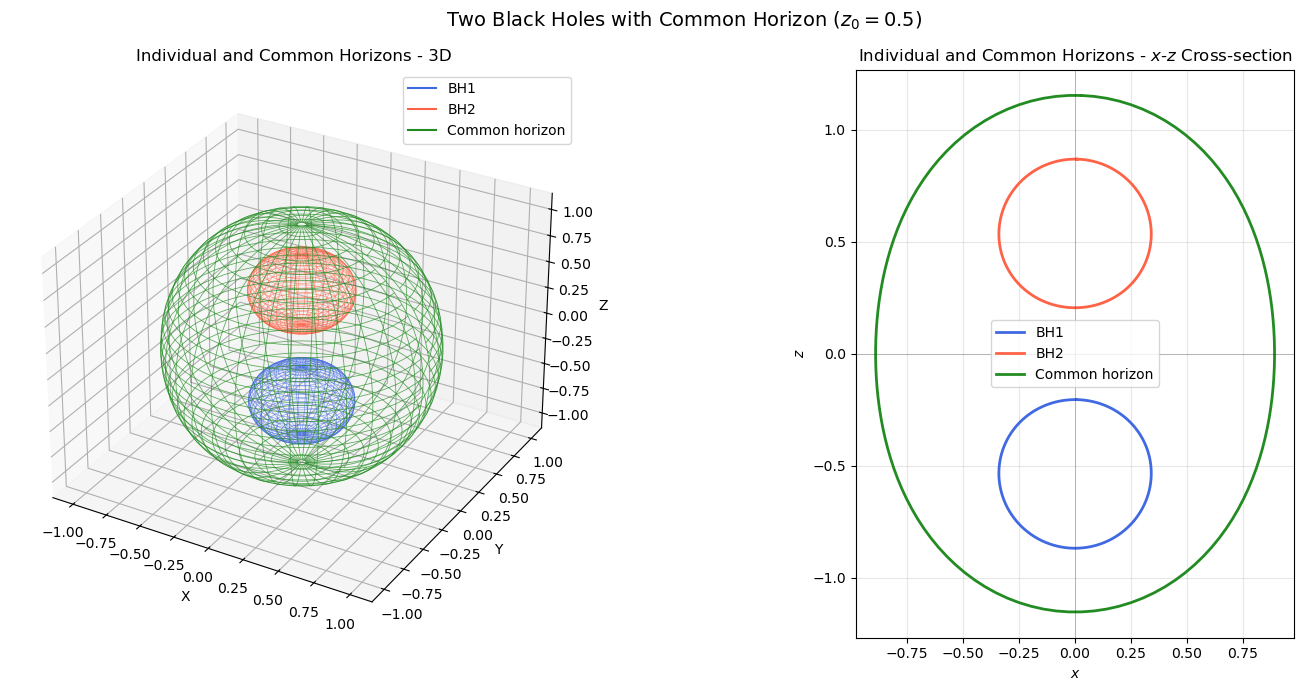

In [22]:
M1, M2 = 1.0, 1.0
z0 = 0.5

THETA1, PHI1 = np.meshgrid(theta1, phi1, indexing='ij')
X1 = h1 * np.sin(THETA1) * np.cos(PHI1)
Y1 = h1 * np.sin(THETA1) * np.sin(PHI1)
Z1 = h1 * np.cos(THETA1) - z0

THETA2, PHI2 = np.meshgrid(theta2, phi2, indexing='ij')
X2 = h2 * np.sin(THETA2) * np.cos(PHI2)
Y2 = h2 * np.sin(THETA2) * np.sin(PHI2)
Z2 = h2 * np.cos(THETA2) + z0

THETA_C, PHI_C = np.meshgrid(theta_c, phi_c, indexing='ij')
XC = h_c * np.sin(THETA_C) * np.cos(PHI_C)
YC = h_c * np.sin(THETA_C) * np.sin(PHI_C)
ZC = h_c * np.cos(THETA_C)

def meridional_curve(h, theta, phi, z_centre=0.0):
    idx0 = 0
    idx_pi = len(phi) // 2

    x_right = h[:, idx0] * np.sin(theta)
    z_right = h[:, idx0] * np.cos(theta) + z_centre

    x_left = -h[:, idx_pi] * np.sin(theta)
    z_left = h[:, idx_pi] * np.cos(theta) + z_centre

    x_closed = np.concatenate([x_right, x_left[::-1], [x_right[0]]])
    z_closed = np.concatenate([z_right, z_left[::-1], [z_right[0]]])
    return x_closed, z_closed

x1c, z1c = meridional_curve(h1, theta1, phi1, -z0)
x2c, z2c = meridional_curve(h2, theta2, phi2, +z0)
xcc, zcc = meridional_curve(h_c, theta_c, phi_c, 0.0)

fig = plt.figure(figsize=(16, 7))

ax3d = fig.add_subplot(121, projection='3d')
ax3d.plot_wireframe(X1, Y1, Z1, color='royalblue', linewidth=0.5, alpha=0.6)
ax3d.plot_wireframe(X2, Y2, Z2, color='tomato', linewidth=0.5, alpha=0.6)
ax3d.plot_wireframe(XC, YC, ZC, color='forestgreen', linewidth=0.6, alpha=0.7)
ax3d.set_xlabel('X')
ax3d.set_ylabel('Y')
ax3d.set_zlabel('Z')
ax3d.set_title('Individual and Common Horizons - 3D')
max_r = max(
    np.max(np.abs(X1)), np.max(np.abs(X2)), np.max(np.abs(XC)),
    np.max(np.abs(Z1)), np.max(np.abs(Z2)), np.max(np.abs(ZC)),
)
ax3d.set_xlim([-max_r, max_r])
ax3d.set_ylim([-max_r, max_r])
ax3d.set_zlim([-max_r, max_r])
from matplotlib.lines import Line2D
ax3d.legend(handles=[
    Line2D([0], [0], color='royalblue', label='BH1'),
    Line2D([0], [0], color='tomato', label='BH2'),
    Line2D([0], [0], color='forestgreen', label='Common horizon'),
])

ax2d = fig.add_subplot(122)
ax2d.plot(x1c, z1c, color='royalblue', lw=2, label='BH1')
ax2d.plot(x2c, z2c, color='tomato', lw=2, label='BH2')
ax2d.plot(xcc, zcc, color='forestgreen', lw=2, label='Common horizon')
ax2d.axhline(0, color='k', lw=0.5, alpha=0.3)
ax2d.axvline(0, color='k', lw=0.5, alpha=0.3)
ax2d.set_xlabel(r'$x$')
ax2d.set_ylabel(r'$z$')
ax2d.set_title(r'Individual and Common Horizons - $x$-$z$ Cross-section')
ax2d.set_aspect('equal')
ax2d.grid(True, alpha=0.3)
ax2d.legend()

plt.suptitle(f'Two Black Holes with Common Horizon ($z_0 = {z0}$)', fontsize=14)
plt.tight_layout()

out_dir = Path('./plots')
out_dir.mkdir(exist_ok=True)
out_path = out_dir / f'horizons_z0_{z0:.2f}.png'
fig.savefig(out_path, dpi=300, bbox_inches='tight')
print(f'Saved: {out_path}')

plt.show()

#### Area calculation

In [23]:
T, P = np.meshgrid(theta_c, phi_c, indexing='ij')
X = h_c * np.sin(T) * np.cos(P)
Y = h_c * np.sin(T) * np.sin(P)
Z = h_c * np.cos(T)

eps = 1e-12
r1 = np.sqrt(X**2 + Y**2 + (Z + z0)**2)
r2 = np.sqrt(X**2 + Y**2 + (Z - z0)**2)
r1 = np.maximum(r1, eps)
r2 = np.maximum(r2, eps)
psi_h = 1 + M1 / (2 * r1) + M2 / (2 * r2)

dtheta = theta_c[1] - theta_c[0]
dphi = phi_c[1] - phi_c[0]
half = len(phi_c) // 2

h_t = np.zeros_like(h_c)
h_p = (np.roll(h_c, -1, axis=1) - np.roll(h_c, 1, axis=1)) / (2 * dphi)
h_t[1:-1, :] = (h_c[2:, :] - h_c[:-2, :]) / (2 * dtheta)
h_t[0, :] = (h_c[1, :] - np.roll(h_c[0, :], half)) / (2 * dtheta)
h_t[-1, :] = (np.roll(h_c[-1, :], half) - h_c[-2, :]) / (2 * dtheta)

sin_T = np.sin(T)
integrand = (psi_h**4 * h_c * np.sqrt(h_c**2 * sin_T**2 + h_t**2 * sin_T**2 + h_p**2))

A_AH = np.sum(integrand) * dtheta * dphi
M_total = M1 + M2
A_norm = A_AH / (16 * np.pi * M_total**2)

print(f'A_AH            = {A_AH:.6f}')
print(f'A/(16 pi M^2)   = {A_norm:.6f}')
print('Shibata ref     = 0.99648  (r_BH/m = 1.00 or z0 = 0.5)')

A_AH            = 200.377623
A/(16 pi M^2)   = 0.996597
Shibata ref     = 0.99648  (r_BH/m = 1.00 or z0 = 0.5)
